# Gold & Real Yields — does 'gold hates rising real rates' tell you *when* to own it? 🥇
### Separating a true same-day fact from a false forecast, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Inverse_link: Confirmed_but_untradable](https://img.shields.io/badge/Inverse_link-Confirmed_but_untradable-8b949e?style=flat-square)

Gold pays no interest. So the story goes: when the *real* interest rate on safe bonds (the yield after subtracting expected inflation) **falls**, the opportunity cost of parking money in shiny metal drops, and gold rises; when real rates **climb**, gold should sink. It is one of the most-repeated lines in macro.

There are actually **two** claims hiding in that sentence, and they are worlds apart:

1. **Same-day:** *do gold and real yields move in opposite directions on the same day?*
2. **Forecast:** *if real yields have been falling lately, will gold rise from here?*

The first can be true while the second is worthless — and that is exactly what we find.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_real_yield import data, strategy as st

def load_real():
    """Cache-first real daily tape (empty frame offline)."""
    try:
        return data.load_series()
    except FileNotFoundError:
        return pd.DataFrame()

DF = load_real()
HAVE_REAL = not DF.empty
print("real gold/real-yield tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF):,} days, {DF.index[0].date()} -> {DF.index[-1].date()})")


real gold/real-yield tape present: True (5,434 days, 2004-11-19 -> 2026-06-29)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do gold and real yields move oppositely *on the same day*? | **Yes — strongly.** Their daily correlation is **-0.26** (rock-solid, *t* -9.67). The famous inverse fact is **real**. |
| Does a *falling* real-yield trend predict *higher* gold next month? | **No.** The fastest-falling-yield days went on to earn **+0.93%** vs **+1.16%** for the fastest-*rising* — a **-0.23%** gap, i.e. faintly the **wrong** way, and statistically nothing. |
| Could you trade it? | **No.** A timer that owns gold only when real yields are falling just *ties* buy-and-hold — and only by hiding in cash half the time — while flipping in and out ~17 times a year. |

> The inverse link is a **same-day mirror**, not a **crystal ball**. Gold *co-moves* with real yields; it is not *timed* by their trend.

## 1 · The claim

> *"Gold has no yield, so it is priced off the real interest rate: real rates down → gold up, real rates up → gold down."* — the practitioner staple, rooted in Barsky & Summers (1988) and sharpened by Erb & Harvey (2013).

The intuition is clean. Holding gold means giving up the real return you *could* have earned on an inflation-protected bond. When that real return shrinks, gold looks better; when it grows, gold looks worse. The 2013 'taper tantrum' — real yields spiked, gold crashed — is the poster child.

## 2 · So what?

If the real-yield *trend* actually timed gold, you'd have a clean macro switch: own gold when real rates are falling, step aside when they're rising. That's the difference between a *fact* (gold reacts to today's rate move) and an *edge* (you can act on yesterday's trend and profit). The desk has looked at gold's session split ([640](../../640-gold-overnight/)) and its calendar ([649](../../649-gold-seasonality/)); here we test the biggest *fundamental* story of all.

## 3 · How would we even know?

1. **Measure the real yield.** The official 10-year real yield isn't a free ticker, so we use a clean stand-in: the **TIPS ETF (TIP)**. Inflation-protected bonds rise exactly when real yields fall, so TIP's recent return *is* a real-yield-fall meter.
2. **The same-day check.** Line up each day's gold move against that day's real-yield move. A strong negative match confirms the fact.
3. **The forecast check.** Rank each day by how much real yields have *fallen* over the last quarter, split days into five buckets, and see how gold did over the *next month*. The claim says the biggest-fall bucket wins.

*Timing:* the trend at today's close forms the signal; we act at *tomorrow's* close (a one-day lag) — no peeking.

## 4 · The teardown — let's actually look

**First, the same-day fact.** Does gold really move opposite to real yields?

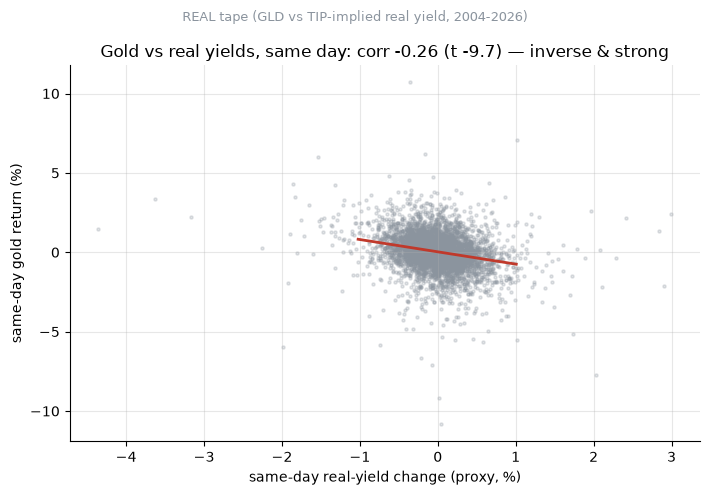

same-day correlation -0.26  (HAC t -9.7) -> the inverse link is REAL


In [2]:
if HAVE_REAL:
    il = st.inverse_link(DF)
    corr, t = il['corr'], il['t']
    g = np.log(DF['GLD_close']).diff(); dry = -np.log(DF['TIP_close']).diff()
    d = pd.DataFrame({'g':g*100,'dry':dry*100}).dropna()
    banner = 'REAL tape (GLD vs TIP-implied real yield, 2004-2026)'
else:
    corr, t = -0.26, -9.67
    rng = np.random.default_rng(0); dry_ = rng.normal(0,0.05,4000)
    d = pd.DataFrame({'dry':dry_*100, 'g':(-0.8*dry_+rng.normal(0,0.09,4000))*100})
    banner = 'illustrative (offline)'
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.scatter(d['dry'], d['g'], s=5, alpha=.25, color=GREY)
b = np.polyfit(d['dry'], d['g'], 1)
xs = np.linspace(d['dry'].quantile(.01), d['dry'].quantile(.99), 50)
ax.plot(xs, np.polyval(b, xs), color=RED, lw=2)
ax.set_xlabel('same-day real-yield change (proxy, %)'); ax.set_ylabel('same-day gold return (%)')
ax.set_title(f'Gold vs real yields, same day: corr {corr:+.2f} (t {t:+.1f}) — inverse & strong')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'same-day correlation {corr:+.2f}  (HAC t {t:+.1f}) -> the inverse link is REAL')

There's the famous fact, confirmed: a same-day correlation of **-0.26** with a *t*-stat of **-9.67** (anything past ±2 is significant; this is off the charts). Gold and real yields genuinely mirror each other. **But** — this is a *same-day* mirror. To profit you'd need to know today's yield move before it happens. So let's ask the question that could actually pay.

**Now the forecast.** If real yields have been *falling*, does gold rise over the next month? Split days into five buckets by the real-yield-fall trend and compare forward gold.

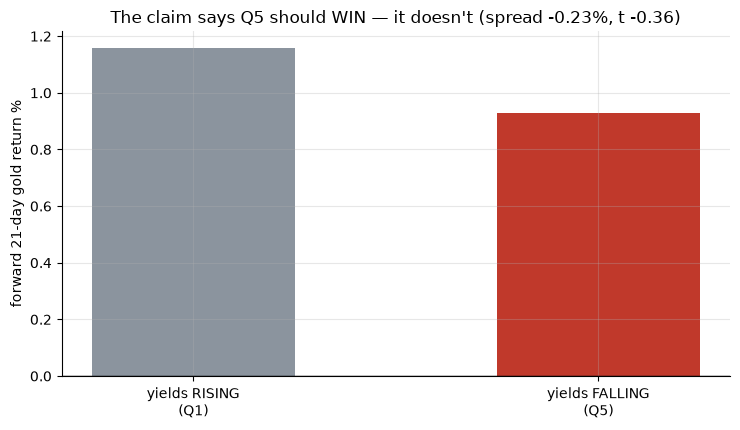

yields rising -> +1.16% | yields falling -> +0.93%  ->  spread -0.23% (HAC t -0.36)


In [3]:
if HAVE_REAL:
    qs = st.quintile_spread(DF, horizon=21, lookback=63)
    q1, q5, spr, t = qs['q1']*100, qs['q5']*100, qs['spread']*100, qs['t']
else:
    q1, q5, spr, t = 1.16, 0.93, -0.23, -0.36
fig, ax = plt.subplots(figsize=(7.5, 4.4))
cols = [GREY, RED if spr < 0 else GREEN]
ax.bar(['yields RISING\n(Q1)','yields FALLING\n(Q5)'], [q1, q5], color=cols, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward 21-day gold return %')
ax.set_title(f'The claim says Q5 should WIN — it doesn\'t (spread {spr:+.2f}%, t {t:+.2f})')
plt.tight_layout(); plt.show()
print(f'yields rising -> +{q1:.2f}% | yields falling -> +{q5:.2f}%  ->  spread {spr:+.2f}% (HAC t {t:+.2f})')

The forecast **fails**. Days after real yields fell fastest earned **+0.93%** over the next month — *less* than the **+1.16%** after yields *rose* fastest. The gap is **-0.23%**, pointing the wrong way, with a *t*-stat of **-0.36** (you want ≥ 2) and a shuffle test that says a gap this size is pure chance **73%** of the time. The trend of real yields tells you nothing useful about *tomorrow's* gold.

## 5 · The verdict

- **Signal — None.** The real-yield *trend* doesn't forecast gold (spread -0.23%, wrong sign, *t* -0.36, shuffle *p* 0.734).
- **Tradability — Mirage.** A timer on the signal ties buy-and-hold only by cash-drag and loses on average return (next notebook).
- **Inverse link — Confirmed but untradable.** The same-day correlation is real and strong (-0.26, *t* -9.67) — but same-day is not a forecast.

## 6 · Could you actually trade it?

No. A timer that owns gold only when real yields are falling sits in cash about half the time — so it *looks* a touch smoother (a near-identical Sharpe) but doesn't actually earn more; on the honest measure (average return) it **loses** to plain buy-and-hold, after flipping in and out ~17 times a year. The next notebook does the cost maths in full.

## 7 · Going further 🚪

- **Same asset, other angles.** [640 Gold-Overnight](../../640-gold-overnight/) (session split), [649 Gold-Seasonality](../../649-gold-seasonality/) (calendar), [580 Gold-Lease-Rate](../../580-gold-lease-rate/) (carry).
- **The breakeven cousin.** [381 TIPS-Breakeven](../../381-tips-breakeven/) trades the inflation-compensation spread itself; here TIP/IEF only *build the real-yield gauge* for timing gold.
- **The real DFII10 tape.** Re-run with the official 10-year TIPS real yield (a FRED CSV, not a free ticker) — but note the failure here isn't the proxy: the proxy *does* deliver the strong same-day link; it's the *forecast* that's missing.

*Think the trend really times gold and we used too crude a gauge? Fork this, drop in DFII10, and show the falling-yield bucket beating the rising-yield bucket at t = 2 out of sample.*